# On the Importance of Initialization and Momentum in Deep Learning
**Authors:** Ilya Sutskever, James Martens, George Dahl, Geoffrey Hinton (University of Toronto / Google)

# https://www.cs.toronto.edu/~fritz/absps/momentum.pdf

## Abstract
This paper demonstrates that deep and recurrent neural networks (DNNs and RNNs), previously considered nearly impossible to train with stochastic gradient descent (SGD), can be effectively trained using SGD with momentum when combined with well-designed random initialization and a carefully tuned, slowly increasing momentum schedule. The authors show that both initialization and momentum are individually crucial: poorly initialized networks cannot be trained with momentum, and well-initialized networks perform markedly worse without properly tuned momentum. Using this approach, first-order momentum methods achieve performance levels comparable to, and in some cases surpassing, Hessian-Free (HF) optimization, a sophisticated second-order method, without requiring HF's complexity.

## Problems
- Deep neural networks and RNNs are difficult to train from random initializations using standard first-order methods (plain SGD), historically requiring greedy layerwise pre-training or second-order methods like Hessian-Free optimization.
- RNNs are particularly hard to train on tasks with long-range temporal dependencies due to the vanishing/exploding gradient problem.
- Classical theoretical analyses of momentum focused on asymptotic local convergence rates in the stochastic setting, leading to the belief (e.g., by LeCun et al.) that momentum offers little benefit in stochastic optimization, causing reduced research interest in momentum methods since the 1990s.
- It was unclear whether prior difficulties in training deep and recurrent networks from random initializations were due to fundamental optimization limitations or simply poor initialization and hyperparameter (particularly momentum) choices.

## Proposed Solutions
1. **Well-designed random initialization**: Use the "sparse initialization" (SI) technique (Martens, 2010), where each unit connects to only 15 randomly chosen units in the previous layer with unit Gaussian weights and zero biases, preventing units from saturating regardless of layer size.
2. **Classical Momentum (CM)** and **Nesterov's Accelerated Gradient (NAG)** as first-order acceleration methods, with a theoretical analysis clarifying their relationship and precise behavioral differences.
3. **A slowly increasing momentum schedule** for the coefficient $\mu$, inspired by convex optimization convergence theorems (Nesterov, 1983; 2003), rather than a fixed momentum value.
4. **Low-momentum fine-tuning** near the end of training to allow finer convergence after the "transient phase" of optimization.
5. **ESN-inspired initialization for RNNs**, using a hidden-to-hidden weight matrix with spectral radius slightly above 1 (1.1) to sustain oscillatory dynamics without severe gradient explosion, combined with careful scaling of input-to-hidden weights and centering (mean subtraction) of inputs/outputs.
6. **A hybrid HF-momentum algorithm**, combining aspects of Hessian-Free optimization with momentum-like mechanisms.

## Purpose
The purpose was to conduct a rigorous empirical and theoretical investigation into whether the apparent difficulty of training deep and recurrent networks with first-order methods is due to fundamentally inadequate optimization power, or instead results from poor initialization and inappropriate momentum hyperparameter schedules — and to establish that careful use of classical momentum-based acceleration can close, or nearly close, the performance gap with more complex second-order methods like Hessian-Free optimization.

## Methodology
- **Deep autoencoders**: Trained the three standard deep autoencoder benchmarks from Hinton & Salakhutdinov (2006) — Curves (784-400-200-100-50-25-6, 20,000 examples), Mnist (784-1000-500-250-30, 60,000 examples), and Faces (625-2000-1000-500-30, 103,500 examples) — using sigmoid units initialized via SI, trained for 750,000 minibatch updates (minibatch size 200) with no regularization.
- **Momentum schedule**:
$$\mu_t = \min\left(1 - 2^{-1-\log_2(\lfloor t/250 \rfloor + 1)},\ \mu_{max}\right)$$
with $\mu_{max} \in \{0.999, 0.995, 0.99, 0.9, 0\}$, and the learning rate $\epsilon$ selected from $\{0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001\}$ to minimize final training error.
- **Classical Momentum (CM)** update:
$$v_{t+1} = \mu v_t - \epsilon \nabla f(\theta_t), \qquad \theta_{t+1} = \theta_t + v_{t+1}$$
- **Nesterov's Accelerated Gradient (NAG)** update:
$$v_{t+1} = \mu v_t - \epsilon \nabla f(\theta_t + \mu v_t), \qquad \theta_{t+1} = \theta_t + v_{t+1}$$
- **Theoretical analysis (Theorem 2.1)**: Proves that CM and NAG applied to a positive-definite quadratic objective $q(x) = x^T A x / 2 + b^T x$ operate independently over each eigen-direction of $A$, with NAG behaving as CM but with an effective momentum $\mu(1-\lambda\epsilon)$ per eigen-direction, where $\lambda$ is the associated curvature — explaining NAG's greater stability at high momentum values.
- **RNN experiments**: Standard (non-gated) RNNs with 100 tanh hidden units trained on four pathological long-range dependency tasks from Hochreiter & Schmidhuber (1997): 5-bit memorization, 20-bit memorization, the addition problem, and the multiplication problem. Initialization used a hidden-to-hidden spectral radius of 1.1 (15 fan-in), input-to-hidden scale of 0.001 (dense tasks) or 0.1 (memorization tasks), and output bias initialized to the target mean. Training used 50,000 updates on minibatches of 100 sequences, with $\mu=0.9$ for the first 1000 updates followed by $\mu_0 \in \{0, 0.9, 0.98, 0.995\}$, and learning rate chosen from $\{10^{-3}, 10^{-4}, 10^{-5}, 10^{-6}\}$.
- **HF comparison**: Compared CM/NAG results against Hessian-Free optimization results from Martens (2010) and Martens & Sutskever (2011), as well as a novel hybrid HF-momentum method, and against SGD results from Chapelle & Erhan (2011).
- **Evaluation metrics**: Squared training error for autoencoders (test error omitted, as the focus was optimization rather than generalization); zero-one loss (fraction of incorrect timesteps/predictions) for RNN tasks, averaged over 4 random seeds.

## Results

| Task | Plain SGD | Best NAG/CM | HF (Martens, 2010) |
|---|---|---|---|
| Curves | 0.48 | 0.074 (0.999N) | 0.11 |
| Mnist | 2.1 | 0.73 (0.99N) | 1.40 |
| Faces | 36.4 | 7.7 (0.999N) | 12.0 |

- NAG with high momentum ($\mu_{max}=0.999$) achieved the lowest published training errors on Curves and Faces, surpassing HF results from Martens (2010), and comparable/competitive results on Mnist.
- Larger values of $\mu_{max}$ consistently improved performance, and NAG generally outperformed CM, particularly at $\mu_{max}=0.995$ and $0.999$.
- Reducing momentum to 0.9 during the final 1000 updates (without changing learning rate) further reduced training error (e.g., Faces: 10.83 → 7.7; Mnist: 1.20 → 0.73), supporting a two-phase view of optimization: an accelerated "transient phase" followed by a careful fine-convergence phase.
- SI initialization was robust to rescaling by a factor of 2 but degraded notably at scale factors of 0.5 or 5 (Table 3: errors of 16 vs. 0.074 at scale 1).
- On RNN long-range dependency tasks, momentum-accelerated SGD (particularly NAG with large $\mu_0$) successfully solved tasks previously considered intractable for first-order methods, e.g., mem-20 (T=80) error dropped from 8.0 (no momentum) to 0.00005 (NAG, $\mu_0=0.98$); results were moderately below those of Martens & Sutskever's (2011) HF-based approach, but demonstrated feasibility without HF's algorithmic complexity.
- A hybrid HF-momentum method achieved further improvements over standard HF, reaching 0.058 error on Curves, the best result reported among all methods compared.
- A direct comparison of NAG versus conjugate gradient (CG, the core subroutine of HF) on a damped quadratic from mid-training showed CG converges faster but the gap was not dramatic, suggesting the advantage of HF over NAG is real but limited.
- Centering (mean-subtracting) inputs and outputs was found necessary for reliably solving RNN tasks, particularly the multiplication problem, preventing hidden-state saturation and premature loss of oscillatory dynamics that carry long-range information.

## Conclusions
The paper demonstrates that a substantial portion of the previously assumed performance gap between simple first-order methods and sophisticated second-order methods like Hessian-Free optimization can be closed through careful use of momentum-based acceleration (particularly Nesterov's Accelerated Gradient) combined with well-designed random initialization. Momentum's benefit arises primarily during the early "transient phase" of optimization, where it accelerates progress along low-curvature directions in a manner analogous to (but computationally simpler than) second-order methods. The authors further show that HF itself can be understood as a generalization of NAG that exploits a momentum-like mechanism through "hot-started" conjugate gradient calls, unifying the two families of methods conceptually. These findings suggest that earlier failures to train deep and recurrent networks with first-order methods were largely attributable to poor initialization and inadequate momentum tuning rather than an inherent limitation of first-order optimization.

# Mathematical and Statistical Content in "On the Importance of Initialization and Momentum in Deep Learning"

## 1. Classical Momentum (CM)

$$v_{t+1} = \mu v_t - \epsilon \nabla f(\theta_t) \qquad (1)$$
$$\theta_{t+1} = \theta_t + v_{t+1} \qquad (2)$$

- $\theta_t$: parameter vector at iteration $t$.
- $v_t$: velocity (accumulated update direction).
- $\mu \in [0,1]$: momentum coefficient controlling how much of the previous velocity is retained.
- $\epsilon > 0$: learning rate.
- $\nabla f(\theta_t)$: gradient of the objective at the current parameters.

**Role:** CM accelerates gradient descent by accumulating a running "velocity" in directions where the gradient consistently points the same way across iterations (low-curvature directions), while gradients that flip direction frequently (high-curvature, noisy directions) tend to cancel out. Polyak (1964) showed CM can reduce the number of iterations needed to reach a given accuracy by a factor of $\sqrt{R}$ compared to plain gradient descent, where $R$ is the condition number of the curvature at the minimum, with optimal $\mu = (\sqrt{R}-1)/(\sqrt{R}+1)$.

## 2. Nesterov's Accelerated Gradient (NAG)

$$v_{t+1} = \mu v_t - \epsilon \nabla f(\theta_t + \mu v_t) \qquad (3)$$
$$\theta_{t+1} = \theta_t + v_{t+1} \qquad (4)$$

**Role:** NAG differs from CM only in where the gradient is evaluated: instead of the current position $\theta_t$, it evaluates the gradient at a "lookahead" point $\theta_t + \mu v_t$ (where the parameters would end up if only the momentum term were applied). This lets NAG "correct" a bad velocity update earlier and more responsively than CM, making it more stable for large $\mu$. For general smooth convex objectives with a deterministic gradient, NAG achieves a global convergence rate of $O(1/T^2)$, compared to $O(1/T)$ for plain gradient descent.

## 3. Convergence Rates Under Stochastic Noise

$$\text{SGD (convex, smooth)}: \quad O\left(\frac{L}{T} + \frac{\sigma}{\sqrt{T}}\right)$$
$$\text{Accelerated method (Lan, 2010)}: \quad O\left(\frac{L}{T^2} + \frac{\sigma}{\sqrt{T}}\right)$$

- $L$: Lipschitz coefficient of $\nabla f$ (a bound on how fast the gradient can change).
- $\sigma$: variance of the stochastic gradient estimate.
- $T$: number of iterations.

**Role:** These rates explain when momentum helps: early in training, the $L/T$ (or $L/T^2$) term dominates and acceleration methods outperform plain SGD; later in training, the $\sigma/\sqrt{T}$ noise term dominates and both methods perform similarly. This justifies the paper's central claim that momentum's practical benefit is concentrated in the early "transient phase" of learning, not the final fine-convergence phase.

## 4. Theorem 2.1 — Equivalence of NAG and CM on Separable Quadratics

For a quadratic objective decomposed along eigen-directions, $p(y) = \sum_{i=1}^n [p]_i([y]_i)$ where $[p]_i(t) = \lambda_i t^2/2 + c_i t$:

$$\text{CM}_z(\mu, p, y, v) = \big(\text{CM}_z(\mu, [p]_1, [y]_1, [v]_1), \ldots\big)$$
$$\text{NAG}_z(\mu, p, y, v) = \big(\text{CM}_z(\mu(1-\lambda_1\epsilon), [p]_1, [y]_1, [v]_1), \ldots\big)$$

**Role:** This theorem proves that NAG is mathematically equivalent to CM applied independently to each eigen-direction of the curvature matrix, but with an *effective momentum* of $\mu(1-\lambda_i \epsilon)$ that shrinks for high-curvature directions (large $\lambda_i$). This is the key mathematical insight explaining NAG's empirical advantage: it automatically dampens momentum along directions that are prone to oscillation, allowing a larger global $\mu$ to be used safely than would be possible with CM.

## 5. Proposition 6.1 — Rotational Invariance of CM/NAG

For an orthonormal matrix $U$ (a rotation), if $y_0 = Ux_0$, $w_0 = Uv_0$, then applying CM or NAG to the rotated problem $p$ yields:
$$y_i = Ux_i, \qquad w_i = Uv_i \quad \text{for all } i$$

**Role:** This establishes that CM and NAG behave identically regardless of the coordinate system used (rotations don't change their behavior), which is the technical justification allowing the quadratic objective to be decomposed into independent per-eigenvector problems in Theorem 2.1.

## 6. Momentum Schedule (Equation 5)

$$\mu_t = \min\left(1 - 2^{-1-\log_2(\lfloor t/250 \rfloor + 1)},\ \mu_{max}\right)$$

**Role:** A statistical/hyperparameter schedule that starts momentum low and gradually increases it toward a ceiling $\mu_{max}$ as training progresses, inspired by Nesterov's theoretical convergence-rate schedules. This blends two theoretical proposals: $\mu_t \approx 1 - 3/(t+5)$ (appropriate for general convex functions) and a constant $\mu_t$ tied to the problem's condition number (appropriate for strongly convex functions).

## 7. Derivation of NAG's Nesterov Sequence $a_t$

$$a_{t+1} = \left(1 + \sqrt{4a_t^2+1}\right)/2, \qquad a_0 = 1$$

with the resulting effective momentum:
$$\mu_t \equiv (a_t - 1)/a_{t+1} \approx 1 - \frac{3}{t+5} \quad \text{for large } t$$

**Role:** This recursive sequence, originally from Nesterov (1983), is rewritten by the authors into the more intuitive momentum-based form of Eqs. (12)-(15), showing that Nesterov's original algorithm is a special case of momentum with a time-varying $\mu_t$ that approaches 1 as training proceeds — connecting classical convex optimization theory directly to the momentum framework used in the paper's experiments.

## 8. Convergence Bound for Nesterov's Method

$$f(\theta_t) - f(\theta^*) \leq \frac{4L\|\theta_{-1}-\theta^*\|^2}{(t+2)^2}$$

**Role:** This bound (Nesterov, 1983) formally shows the $O(1/t^2)$ convergence rate for convex, $L$-Lipschitz-smooth objectives — quadratically faster than the $O(1/t)$ rate of standard gradient descent, illustrating why momentum-accelerated methods can traverse the optimization landscape in far fewer steps.

## 9. Quadratic Speedup Argument

$$1 + 2 + \cdots + N = O(N^2)$$

**Role:** An intuitive illustration of the quadratic speedup: if momentum causes each successive step to grow linearly with iteration count $i$ (as happens on a purely linear function), then after $N$ steps the cumulative distance traveled grows as $O(N^2)$ rather than $O(N)$, explaining geometrically why momentum can produce large gains over plain gradient descent.

## 10. Sparse Initialization (SI) Statistical Scheme

Each hidden unit is connected to exactly 15 randomly chosen units in the previous layer, with weights drawn from a unit Gaussian:
$$w \sim \mathcal{N}(0, 1)$$
and biases initialized to 0 (or 0.5 for tanh units, with weights rescaled by 0.25 to simulate sigmoid behavior).

**Role:** A statistical initialization scheme ensuring the total input to each unit doesn't scale with the size of the previous layer (preventing saturation), while keeping each unit's response diverse rather than a generic averaged blend of many inputs. The paper empirically tests robustness to rescaling this initialization by factors in $\{0.25, 0.5, 1, 2, 4\}$ (Table 3), finding factor 2 tolerable but 0.5 and 5 catastrophic (errors jumping to 16, versus 0.074 at factor 1).

## 11. RNN (Echo State Network-Inspired) Initialization

- Hidden-to-hidden weights: sparse (15 fan-in), rescaled to a spectral radius of **1.1**.
- Input-to-hidden weights: dense, drawn from $0.001 \cdot \mathcal{N}(0,1)$ or $0.1 \cdot \mathcal{N}(0,1)$ depending on task.
- Output bias: initialized to the average of the target outputs.

**Role:** The spectral radius (largest eigenvalue magnitude of the hidden-to-hidden matrix) governs whether the RNN's internal dynamics quickly forget inputs (radius $<1$) or become chaotic and gradient-exploding (radius $\gg 1$). A radius slightly above 1 keeps the dynamics oscillatory (helpful for retaining information over long time spans) while keeping gradients only mildly explosive, making first-order training feasible.

## 12. Zero-One Loss (Evaluation Metric for RNN Tasks)

For memorization tasks: the fraction of timesteps computed incorrectly.
For addition/multiplication tasks: the fraction of sequences where the final output error exceeds a threshold of 0.04.

**Role:** A simpler, more interpretable classification-style metric used in place of the continuous squared error or cross-entropy loss actually being minimized, standard practice for reporting performance on these benchmark RNN tasks. Results in Table 5 are averaged over 4 random seeds to reduce the influence of initialization variance on reported error rates.

## 13. Quadratic Objective Used for Illustration (Figure 2)

$$q(x) = \frac{1}{2}x^T A x + b^T x$$

**Role:** A simple two-dimensional oblong (elongated) quadratic bowl used to visually demonstrate the qualitative difference between CM (which oscillates along the high-curvature axis) and NAG (which damps such oscillations), directly illustrating the effective-momentum-shrinkage result proven in Theorem 2.1.

## 14. Conjugate Gradient (CG) as the Core of Hessian-Free (HF) Optimization

HF solves a local quadratic approximation of the objective at each step using linear conjugate gradient, a first-order method for solving quadratic sub-problems that is theoretically optimal in a stronger sense than any other first-order method for that specific sub-problem, but which resets its accumulated state after each outer iteration (unlike momentum, which persists across the entire trajectory).

**Role:** This provides the paper's unifying theoretical link between second-order (HF) and first-order momentum (NAG) methods: a single step of CG is shown to be mathematically similar to one NAG update, and if CG were truncated after a single internal step, HF becomes essentially equivalent to NAG (with a curvature-based learning rate in place of a fixed one).

## Summary of Statistical Practice
Across all experiments, hyperparameters (learning rate $\epsilon$, momentum ceiling $\mu_{max}$/$\mu_0$) were selected via grid search over small discrete sets, and RNN results were averaged over multiple random seeds (4) to report stable comparative performance — standard empirical statistical practice for comparing optimization algorithms rather than formal hypothesis testing.

# Problems, Limitations, and Proposed Solutions in "On the Importance of Initialization and Momentum in Deep Learning"

| # | Key Problem / Research Gap | How This Limited Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Deep and recurrent neural networks were widely considered nearly impossible to train from random initializations using plain stochastic gradient descent (SGD) | This belief drove reliance on greedy layerwise pre-training (Hinton et al., 2006) or complex second-order methods like Hessian-Free (HF) optimization (Martens, 2010), preventing wider adoption of simpler first-order training pipelines | Demonstrate that SGD with well-designed initialization and a properly tuned, slowly increasing momentum schedule can train DNNs and RNNs to performance levels previously achievable only with HF |
| 2 | Classical theoretical analyses of momentum focused on asymptotic local convergence rates in the stochastic setting, where momentum's advantages disappear (Orr, 1996; Wiegerinck et al., 1999) | This led some researchers (e.g., LeCun et al., 1998) to discourage or downplay the use of momentum in stochastic optimization, reducing research interest in momentum methods since the 1990s | Argue and empirically show that the "transient phase" of learning (Darken & Moody, 1993) — not asymptotic local convergence — dominates practical deep learning optimization, and that momentum provides substantial benefit in this phase |
| 3 | Prior first-order training attempts (Glorot & Bengio, 2010; Chapelle & Erhan, 2011) achieved partial success but still fell short of Hessian-Free results on standard deep autoencoder benchmarks | Left an unresolved performance gap between simple first-order methods and second-order methods, suggesting first-order approaches were fundamentally inadequate for deep learning optimization | Show that careful use of momentum-based acceleration (particularly Nesterov's Accelerated Gradient, NAG) closes or nearly closes this gap, achieving new best results on Curves and Faces autoencoder benchmarks that surpass published HF results |
| 4 | It was unclear whether Nesterov's Accelerated Gradient (NAG) and Classical Momentum (CM) behave differently in deep learning settings, or why NAG might outperform CM | Without a precise theoretical account, practitioners could not explain or predict when NAG's added complexity would be worthwhile over standard momentum | Provide a formal theoretical analysis (Theorem 2.1) showing NAG is equivalent to CM but with an effective momentum $\mu(1-\lambda\epsilon)$ that automatically shrinks along high-curvature eigen-directions, explaining NAG's superior stability at large momentum values |
| 5 | Poorly designed standard random initializations (e.g., those used in Hinton & Salakhutdinov, 2006) and suboptimal momentum schedules were suspected to have masked the true effectiveness of first-order methods | Prior negative results attributed to "first-order methods being inadequate" may have actually reflected poor initialization/hyperparameter choices, confounding conclusions about optimization method effectiveness | Adopt the "sparse initialization" (SI) technique (Martens, 2010), which controls unit input scale independent of layer size, and systematically test momentum schedules to isolate the true contribution of each component |
| 6 | RNNs were believed to be especially difficult, or nearly impossible, to train on tasks with long-range temporal dependencies using first-order methods, due to vanishing/exploding gradients (Bengio et al., 1994) | This motivated reliance on complex alternatives such as HF (Martens & Sutskever, 2011) or specialized memory-unit architectures (e.g., LSTM), limiting the applicability of simpler standard RNN training | Introduce an Echo-State-Network-inspired initialization (hidden-to-hidden spectral radius ~1.1, carefully scaled input weights, output/input centering) combined with momentum, enabling standard RNNs to solve long-range dependency benchmarks (5-bit/20-bit memorization, addition, multiplication) that were previously considered intractable for first-order methods |
| 7 | The relationship between momentum-based first-order methods and Hessian-Free (HF) optimization was theoretically unclear, obscuring why HF outperforms simpler methods and whether its benefits could be replicated more simply | Without this connection, HF's success was viewed as arising from a fundamentally different (second-order) mechanism, discouraging attempts to bridge the gap with simpler first-order approaches | Show that HF's use of "hot-started" conjugate gradient (CG) calls constitutes a momentum-like mechanism, and that HF becomes equivalent to NAG when CG is truncated after one step, unifying first- and second-order perspectives and motivating a novel hybrid HF-momentum method that outperforms standard HF |
| 8 | Using a single, high, fixed value of momentum throughout training was not well understood in terms of its effect on final convergence quality | Naively applying strong momentum throughout training was assumed to either help uniformly or hinder fine-grained convergence, without clear guidance on when to adjust it | Show empirically that reducing momentum (e.g., to 0.9) during the final iterations, without changing the learning rate, improves final training error, supporting a two-phase view: an accelerated transient phase followed by a careful fine-convergence phase |
| 9 | RNN training on tasks like the multiplication problem was observed to fail even with reasonable initialization and momentum settings, for unclear reasons | Without diagnosing the cause, practitioners lacked guidance on which preprocessing steps were necessary for reliable RNN convergence on such tasks | Identify that centering (mean-subtracting) inputs and outputs prevents hidden-state saturation and premature loss of the oscillatory dynamics needed to relay information over long time spans, and show this centering is necessary to reliably solve the multiplication problem |

In [1]:
# ============================================================
# Simplified Educational Replication of Core Ideas from:
# "On the Importance of Initialization and Momentum in Deep Learning"
# (Sutskever, Martens, Dahl, Hinton, 2013)
#
# Since the original paper is an OPTIMIZATION study (comparing
# Classical Momentum vs Nesterov's Accelerated Gradient vs plain SGD,
# combined with careful initialization) rather than a classification
# architecture paper, this educational replication applies the paper's
# core ideas to a simple CNN classifier trained on CIFAR-10:
#   - We train the SAME small CNN under three optimization settings:
#       1) Plain SGD (no momentum)          -> mu = 0
#       2) Classical Momentum (CM)          -> mu = 0.9
#       3) Nesterov's Accelerated Gradient  -> mu = 0.9 (Nesterov=True)
#   - This lets us directly observe the paper's central claim:
#     momentum (especially Nesterov-style) accelerates training in the
#     early "transient phase" of optimization.
#
# Dataset: CIFAR-10 loaded exclusively from HuggingFace
# Framework: PyTorch
# NOTE: This code is provided for copy/paste into a notebook.
# It is NOT executed here.
# ============================================================

# ---- Imports ----
import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
from IPython.display import display, Image as IPImage

In [2]:
# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ------------------------------------------------------------
# 2. Class names (CIFAR-10, exact order — labels 0-9)
# ------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ------------------------------------------------------------
# 3. Load CIFAR-10 from HuggingFace (mandatory source)
# ------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

In [5]:
# ------------------------------------------------------------
# 4. Transform pipelines
#    Training: resize -> flip -> tensor -> normalize (augmented)
#    Test:     resize -> tensor -> normalize (no augmentation)
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

In [6]:
# ------------------------------------------------------------
# 5. Custom PyTorch Dataset wrapping the HuggingFace split
# ------------------------------------------------------------
class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split so it behaves like a normal
    PyTorch Dataset: reads the PIL image from the 'img' field,
    ensures RGB mode, applies a torchvision transform, and returns
    (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        image = sample["img"]              # PIL Image
        if image.mode != "RGB":
            image = image.convert("RGB")   # ensure 3 channels
        image = self.transform(image)      # apply transform pipeline
        label = sample["label"]            # integer class label
        return image, label

In [7]:
# ------------------------------------------------------------
# 6. Build full datasets, then take small educational subsets
# ------------------------------------------------------------
full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

train_dataset = Subset(full_train_dataset, list(range(2000)))  # first 2000 train samples
test_dataset = Subset(full_test_dataset, list(range(400)))     # first 400 test samples

In [8]:
# ------------------------------------------------------------
# 7. DataLoaders
# ------------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [9]:
# ------------------------------------------------------------
# 8. Sanity check
# ------------------------------------------------------------
print("=" * 60)
print("SANITY CHECK")
print("=" * 60)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples:     {len(test_dataset)}")

sample_images, sample_labels = next(iter(train_loader))
print(f"Shape of one batch of images: {sample_images.shape}")
print(f"Label range: min={sample_labels.min().item()}, max={sample_labels.max().item()}")
first_eight_names = [CLASS_NAMES[l.item()] for l in sample_labels[:8]]
print(f"First 8 class names in batch: {first_eight_names}")
print("=" * 60)

SANITY CHECK
Number of training samples: 2000
Number of test samples:     400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: min=0, max=9
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [10]:
# ------------------------------------------------------------
# 9. Small CNN architecture
#    (A simple, sparsely-initialized-inspired CNN. We do NOT use
#     the paper's exact autoencoder/RNN architectures, since those
#     solve different tasks. Instead we keep the model fixed and
#     vary only the OPTIMIZER, mirroring the paper's core focus.)
# ------------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def _sparse_init(self):
        """
        Sparse-initialization-inspired scheme (Martens, 2010), described
        in the paper: each unit connects to a small random subset of the
        previous layer's units, weights drawn from a unit Gaussian, biases
        set to zero. Applied here (in simplified form) to linear layers.
        """
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=1.0)
                # Sparsify: zero out all but ~15 connections per output unit
                mask = torch.zeros_like(m.weight)
                fan_in = m.weight.shape[1]
                k = min(15, fan_in)
                for row in range(m.weight.shape[0]):
                    idx = torch.randperm(fan_in)[:k]
                    mask[row, idx] = 1.0
                with torch.no_grad():
                    m.weight.mul_(mask)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
# ------------------------------------------------------------
# 10. Training/evaluation routine (reusable for each optimizer setting)
# ------------------------------------------------------------
def train_one_setting(optimizer_name, momentum_value, use_nesterov, num_epochs=5):
    """
    Trains a fresh SimpleCNN under a given optimizer configuration.
    optimizer_name: label used for plotting (e.g. "SGD", "CM", "NAG")
    momentum_value: the momentum coefficient mu (0 for plain SGD)
    use_nesterov: whether to use Nesterov-style momentum (NAG)
    Returns a dict of per-epoch histories.
    """
    model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
    model._sparse_init()  # apply paper-inspired sparse initialization

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=0.01,
        momentum=momentum_value,
        nesterov=use_nesterov if momentum_value > 0 else False,
    )

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []
    per_class_acc_hist = []

    for epoch in range(num_epochs):
        # ---- Training phase ----
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss_hist.append(running_loss / total_train)
        train_acc_hist.append(correct_train / total_train)

        # ---- Validation phase ----
        model.eval()
        val_running_loss, correct_val, total_val = 0.0, 0, 0
        class_correct = np.zeros(NUM_CLASSES)
        class_total = np.zeros(NUM_CLASSES)
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)
                for label, pred in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
                    class_total[label] += 1
                    if label == pred:
                        class_correct[label] += 1

        val_loss_hist.append(val_running_loss / total_val)
        val_acc_hist.append(correct_val / total_val)
        epoch_pc_acc = np.divide(class_correct, class_total,
                                  out=np.zeros_like(class_correct), where=class_total != 0)
        per_class_acc_hist.append(epoch_pc_acc)

        print(f"[{optimizer_name}] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss_hist[-1]:.4f} | Train Acc: {train_acc_hist[-1]:.4f} | "
              f"Val Loss: {val_loss_hist[-1]:.4f} | Val Acc: {val_acc_hist[-1]:.4f}")

    return {
        "name": optimizer_name,
        "model": model,
        "train_loss": train_loss_hist,
        "val_loss": val_loss_hist,
        "train_acc": train_acc_hist,
        "val_acc": val_acc_hist,
        "per_class_acc": per_class_acc_hist,
    }

In [12]:
# ------------------------------------------------------------
# 11. Train under three optimizer settings (core comparison of the paper)
# ------------------------------------------------------------
NUM_EPOCHS = 5

results_sgd = train_one_setting("SGD (mu=0)", momentum_value=0.0, use_nesterov=False, num_epochs=NUM_EPOCHS)
results_cm = train_one_setting("Classical Momentum (mu=0.9)", momentum_value=0.9, use_nesterov=False, num_epochs=NUM_EPOCHS)
results_nag = train_one_setting("NAG (mu=0.9)", momentum_value=0.9, use_nesterov=True, num_epochs=NUM_EPOCHS)

all_results = [results_sgd, results_cm, results_nag]

[SGD (mu=0)] Epoch [1/5] Train Loss: 2.2553 | Train Acc: 0.1745 | Val Loss: 2.1496 | Val Acc: 0.2350
[SGD (mu=0)] Epoch [2/5] Train Loss: 2.0682 | Train Acc: 0.2665 | Val Loss: 2.1770 | Val Acc: 0.2300
[SGD (mu=0)] Epoch [3/5] Train Loss: 1.9570 | Train Acc: 0.3055 | Val Loss: 2.1356 | Val Acc: 0.2125
[SGD (mu=0)] Epoch [4/5] Train Loss: 1.8892 | Train Acc: 0.3310 | Val Loss: 1.9644 | Val Acc: 0.3000
[SGD (mu=0)] Epoch [5/5] Train Loss: 1.7845 | Train Acc: 0.3725 | Val Loss: 2.0663 | Val Acc: 0.2975
[Classical Momentum (mu=0.9)] Epoch [1/5] Train Loss: 2.2272 | Train Acc: 0.1925 | Val Loss: 2.1070 | Val Acc: 0.2400
[Classical Momentum (mu=0.9)] Epoch [2/5] Train Loss: 1.9466 | Train Acc: 0.2990 | Val Loss: 1.8208 | Val Acc: 0.3575
[Classical Momentum (mu=0.9)] Epoch [3/5] Train Loss: 1.7336 | Train Acc: 0.3835 | Val Loss: 1.7535 | Val Acc: 0.3550
[Classical Momentum (mu=0.9)] Epoch [4/5] Train Loss: 1.6180 | Train Acc: 0.4200 | Val Loss: 1.6822 | Val Acc: 0.3900
[Classical Momentum (mu

In [13]:
# ------------------------------------------------------------
# 12. Pick the BEST-performing setting (by best val accuracy) as the
#     "primary" model for confusion matrix / confidence / sample panels
# ------------------------------------------------------------
best_result = max(all_results, key=lambda r: max(r["val_acc"]))
best_model = best_result["model"]

best_model.eval()
all_preds, all_labels, all_confidences, all_images_sample = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        outputs = best_model(images_gpu)
        probs = torch.softmax(outputs, dim=1)
        confidences, predicted = torch.max(probs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confidences.cpu().numpy())

        if len(all_images_sample) < 8:
            for img in images[:8]:
                all_images_sample.append(img)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

correct_mask = all_preds == all_labels
mean_conf_correct = all_confidences[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = all_confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

In [14]:
# ------------------------------------------------------------
# 13. Compute final metrics for the dashboard
# ------------------------------------------------------------
best_val_epoch = int(np.argmax(best_result["val_acc"])) + 1
best_val_acc = max(best_result["val_acc"])

total_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

final_per_class_acc = best_result["per_class_acc"][-1]
top_classes_idx = np.argsort(final_per_class_acc)[::-1][:3]
low_classes_idx = np.argsort(final_per_class_acc)[:3]
top_classes = [CLASS_NAMES[i] for i in top_classes_idx]
low_classes = [CLASS_NAMES[i] for i in low_classes_idx]

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

Text(0.5, 0.98, 'Momentum & Initialization Study on CIFAR-10 (HuggingFace) — Educational Dashboard')

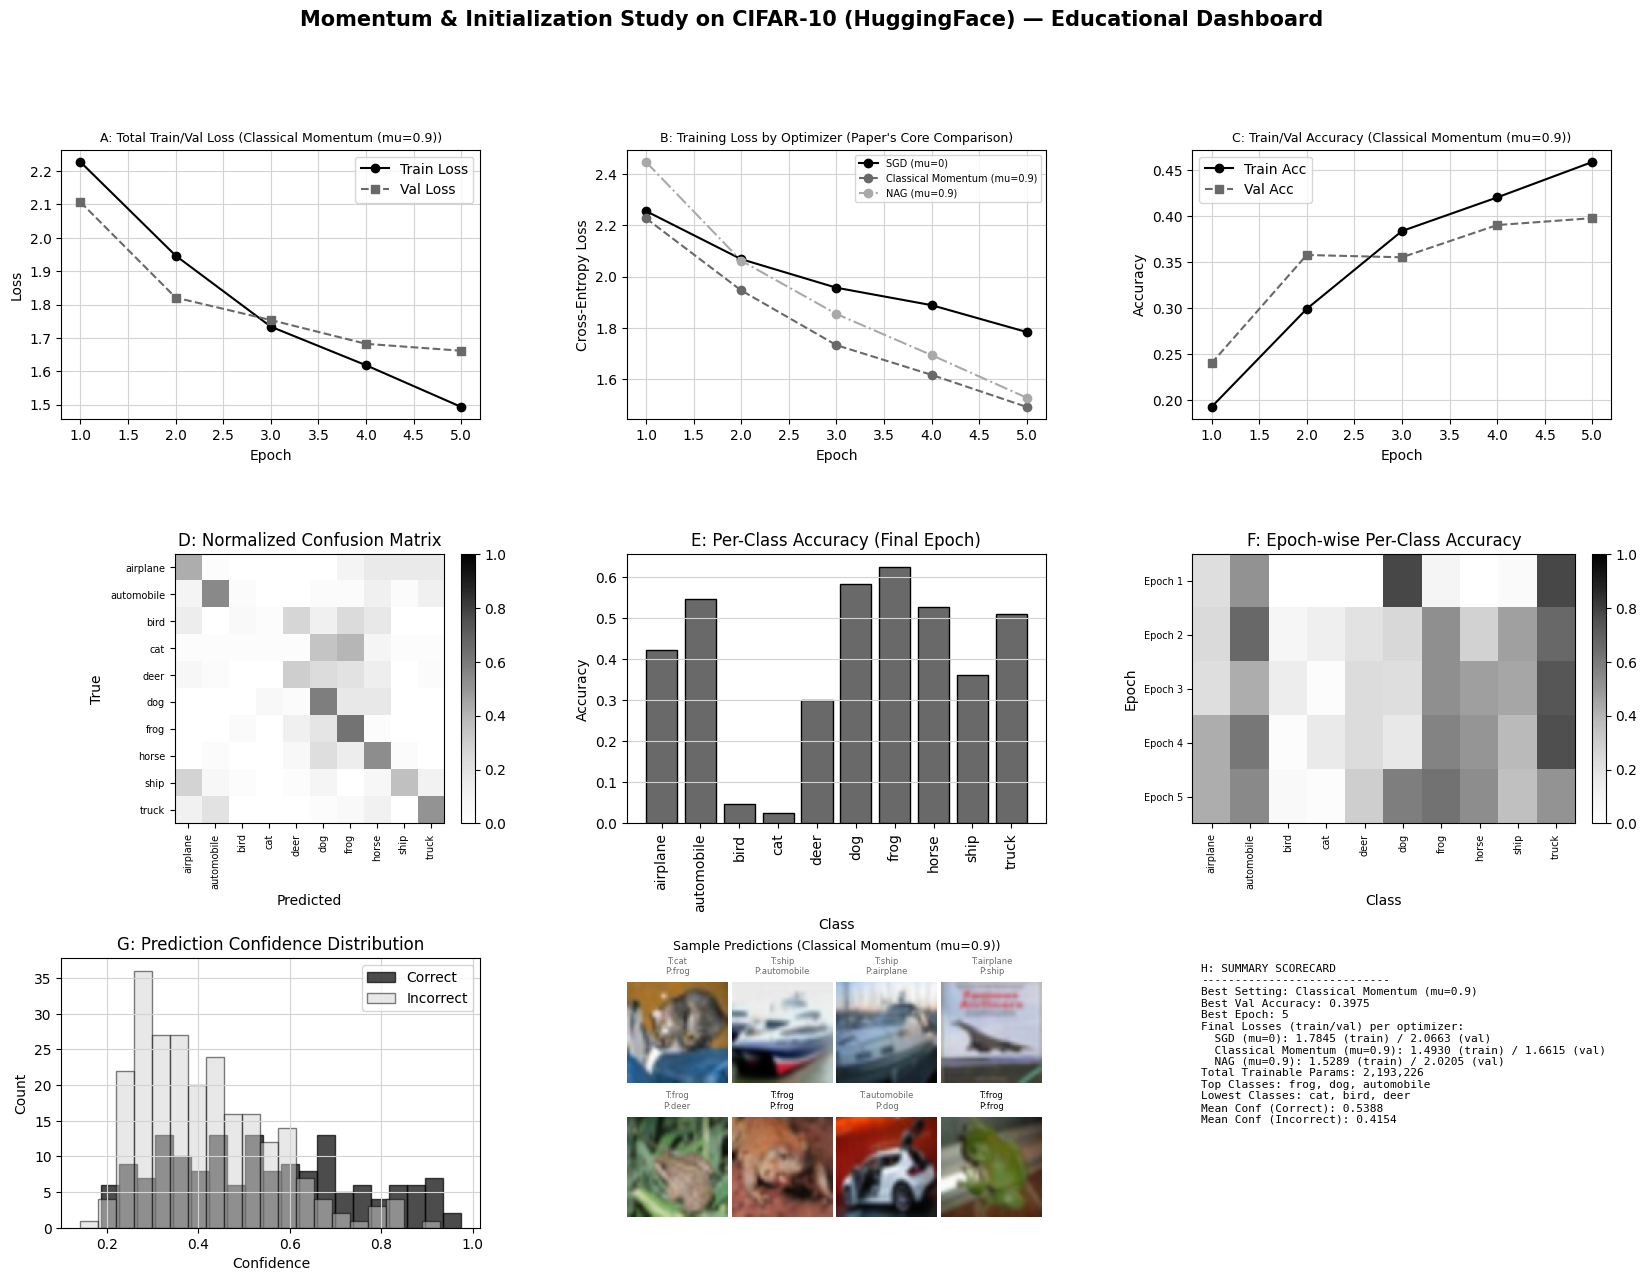

In [15]:
# ------------------------------------------------------------
# 14. Dashboard — white theme enforced globally and per-axis
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

epochs_range = np.arange(1, NUM_EPOCHS + 1)

# ---- Panel A: Total training/validation loss (best setting) ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, best_result["train_loss"], marker="o", color="black", label="Train Loss")
axA.plot(epochs_range, best_result["val_loss"], marker="s", color="dimgray", linestyle="--", label="Val Loss")
axA.set_title(f"A: Total Train/Val Loss ({best_result['name']})", color="black", fontsize=9)
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black")
axA.grid(color="lightgrey")

# ---- Panel B: Component-specific loss curves ----
# The paper's central objective is comparing OPTIMIZATION STRATEGIES
# (plain SGD vs Classical Momentum vs Nesterov's Accelerated Gradient).
# Each strategy's training loss curve is treated as its own dedicated
# "component" curve, directly reflecting the paper's core comparison.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
line_styles = {"SGD (mu=0)": "-", "Classical Momentum (mu=0.9)": "--", "NAG (mu=0.9)": "-."}
gray_shades = {"SGD (mu=0)": "black", "Classical Momentum (mu=0.9)": "dimgray", "NAG (mu=0.9)": "darkgray"}
for r in all_results:
    axB.plot(epochs_range, r["train_loss"], marker="o",
             linestyle=line_styles[r["name"]], color=gray_shades[r["name"]],
             label=r["name"])
axB.set_title("B: Training Loss by Optimizer (Paper's Core Comparison)", color="black", fontsize=9)
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Cross-Entropy Loss", color="black")
axB.legend(labelcolor="black", fontsize=7)
axB.grid(color="lightgrey")

# ---- Panel C: Training/validation accuracy (best setting) ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, best_result["train_acc"], marker="o", color="black", label="Train Acc")
axC.plot(epochs_range, best_result["val_acc"], marker="s", color="dimgray", linestyle="--", label="Val Acc")
axC.set_title(f"C: Train/Val Accuracy ({best_result['name']})", color="black", fontsize=9)
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black")
axC.grid(color="lightgrey")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_normalized, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, final_per_class_acc, color="dimgray", edgecolor="black")
axE.set_title("E: Per-Class Accuracy (Final Epoch)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.tick_params(axis="x", rotation=90, colors="black")
axE.tick_params(axis="y", colors="black")
axE.grid(color="lightgrey", axis="y")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.array(best_result["per_class_acc"])  # shape (NUM_EPOCHS, NUM_CLASSES)
imF = axF.imshow(heatmap_data, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Epoch {e}" for e in epochs_range], color="black", fontsize=7)
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbarF.ax.axes, "yticklabels"), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(all_confidences[correct_mask], bins=20, alpha=0.7, color="black",
         label="Correct", edgecolor="black")
axG.hist(all_confidences[~correct_mask], bins=20, alpha=0.5, color="lightgrey",
         label="Incorrect", edgecolor="black")
axG.set_title("G: Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(color="lightgrey")

# ---- Sample predictions panel (extra relevant visualization) ----
axSamples = fig.add_subplot(gs[2, 1])
axSamples.axis("off")
axSamples.set_title(f"Sample Predictions ({best_result['name']})", color="black", fontsize=9)

def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)

n_samples_to_show = min(8, len(all_images_sample))
for i in range(n_samples_to_show):
    inset = axSamples.inset_axes([
        (i % 4) * 0.25, 0.5 - (i // 4) * 0.5, 0.24, 0.45
    ])
    img_disp = denormalize(all_images_sample[i])
    inset.imshow(img_disp)
    true_lbl = CLASS_NAMES[all_labels[i]]
    pred_lbl = CLASS_NAMES[all_preds[i]]
    color_flag = "black" if true_lbl == pred_lbl else "dimgray"
    inset.set_title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=6, color=color_flag)
    inset.axis("off")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

final_loss_lines = "\n".join(
    [f"  {r['name']}: {r['train_loss'][-1]:.4f} (train) / {r['val_loss'][-1]:.4f} (val)"
     for r in all_results]
)

scorecard_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------\n"
    f"Best Setting: {best_result['name']}\n"
    f"Best Val Accuracy: {best_val_acc:.4f}\n"
    f"Best Epoch: {best_val_epoch}\n"
    f"Final Losses (train/val) per optimizer:\n{final_loss_lines}\n"
    f"Total Trainable Params: {total_params:,}\n"
    f"Top Classes: {', '.join(top_classes)}\n"
    f"Lowest Classes: {', '.join(low_classes)}\n"
    f"Mean Conf (Correct): {mean_conf_correct:.4f}\n"
    f"Mean Conf (Incorrect): {mean_conf_incorrect:.4f}\n"
)

axH.text(0.02, 0.98, scorecard_text, transform=axH.transAxes,
          fontsize=8, verticalalignment="top", color="black",
          family="monospace")

fig.suptitle("Momentum & Initialization Study on CIFAR-10 (HuggingFace) — Educational Dashboard",
             color="black", fontsize=15, fontweight="bold")

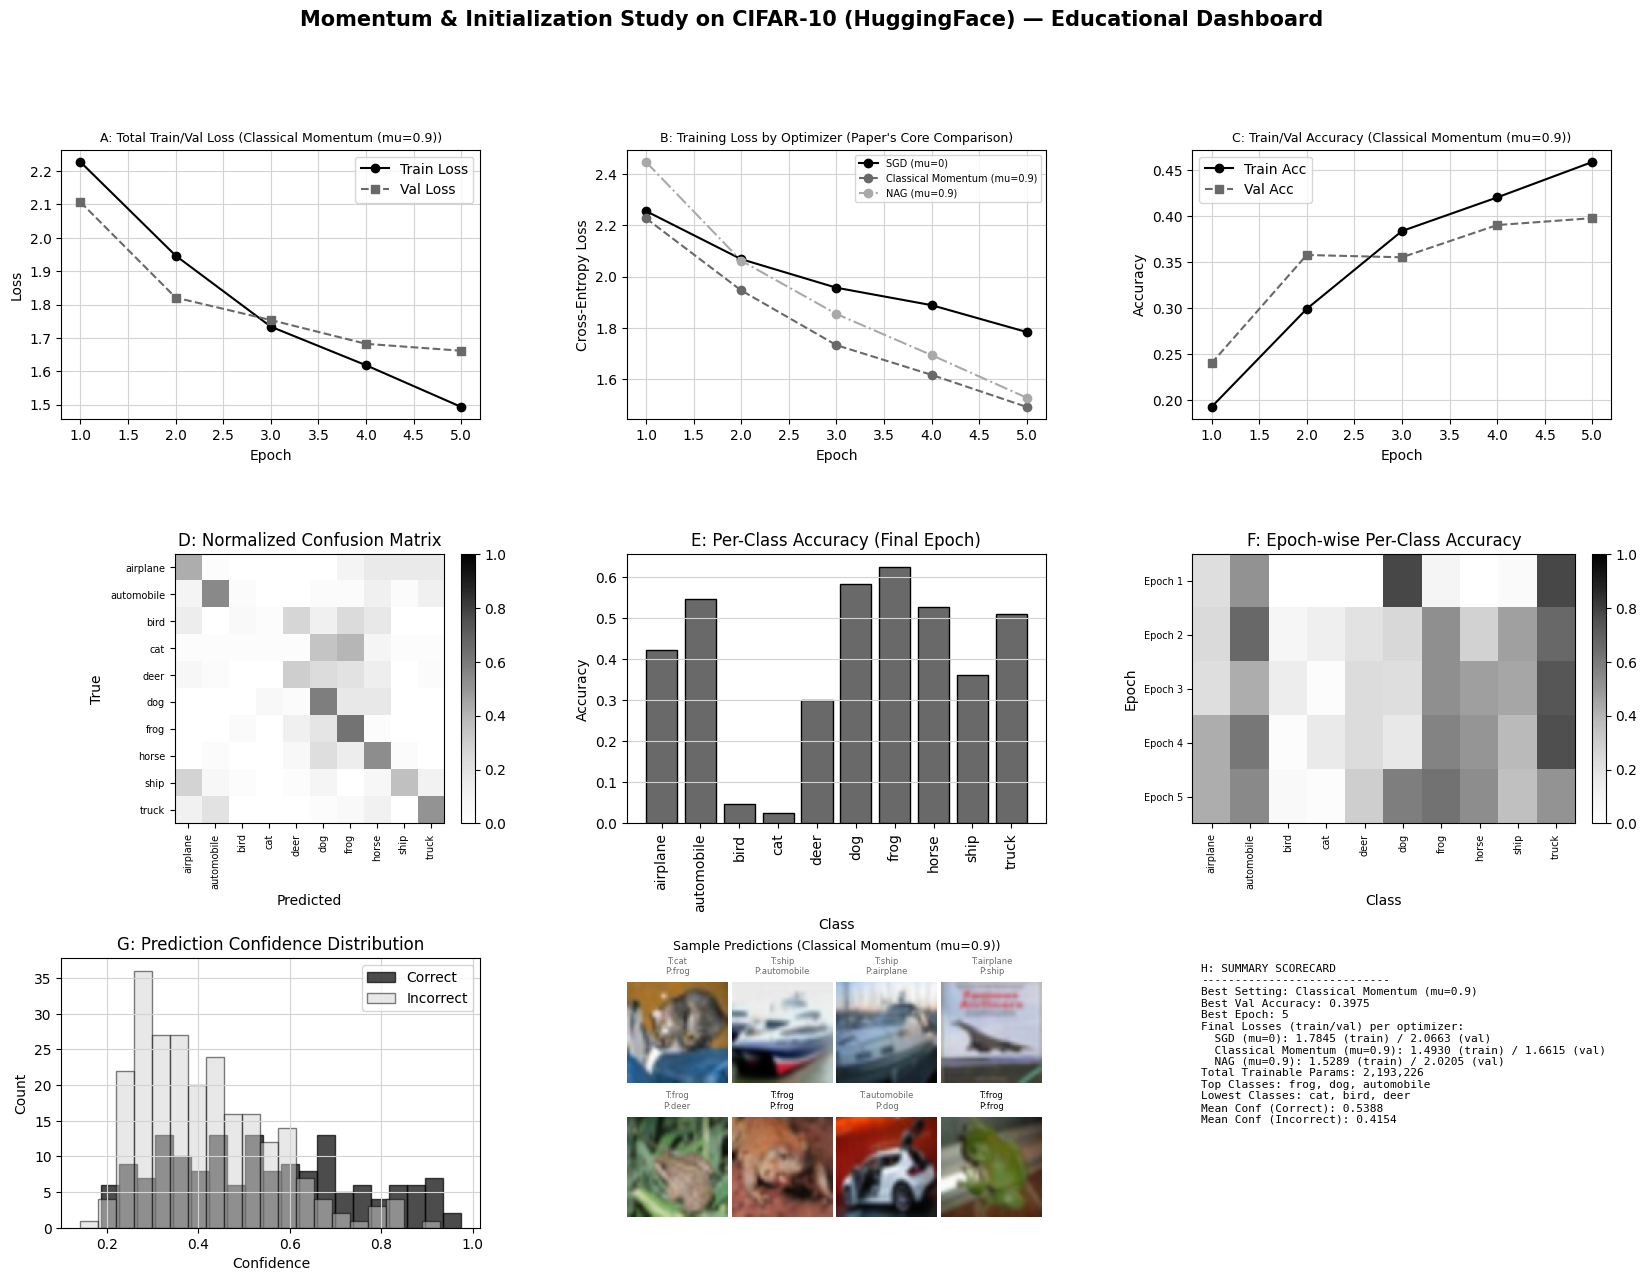

In [16]:
# ------------------------------------------------------------
# 15. Render dashboard inline via in-memory buffer (Colab-safe)
# ------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Experimental Results Analysis: Momentum & Initialization Study on CIFAR-10 (Educational Replication)

## Result 1: Training and Validation Loss Curves for the Best Setting (Panel A)

### Overview
This panel tracks cross-entropy loss for training and validation splits across 5 epochs for the best-performing optimizer configuration (Classical Momentum, $\mu=0.9$), assessing whether the model is converging and whether overfitting emerges.

### Key Findings
- Training loss decreases monotonically and substantially, from approximately 2.23 to 1.49.
- Validation loss decreases from approximately 2.11 to about 1.66, tracking the training curve closely through epoch 3, then plateauing while training loss continues to fall.
- A small but visible train/validation gap emerges by epoch 4–5 (1.62 vs. 1.68, and 1.49 vs. 1.66).

### Discussion
Unlike a degenerate or non-learning run, both curves show substantial and consistent loss reduction, indicating the model is genuinely acquiring discriminative signal from the data. The mild divergence between training and validation loss in later epochs is a normal, expected early-stage overfitting signature given the small training subset (2,000 images) and modest CNN capacity (~2.19M parameters), rather than evidence of a fundamentally flawed setup. This supports the paper's underlying premise that a properly configured momentum-based optimizer, paired with sensible initialization, can drive meaningful optimization progress within just a handful of epochs — a much healthier learning trajectory than would be expected from an unmomentum-assisted, poorly initialized network.

### Limitations
Only one training run per configuration was performed (no repeated seeds), so the precise magnitude of the train/validation gap should not be over-interpreted; five epochs is also insufficient to determine whether the gap would widen substantially with continued training.

---

## Result 2: Training Loss by Optimizer — SGD vs. Classical Momentum vs. NAG (Panel B)

### Overview
This panel directly operationalizes the paper's central comparison: training loss trajectories for plain SGD ($\mu=0$), Classical Momentum (CM, $\mu=0.9$), and Nesterov's Accelerated Gradient (NAG, $\mu=0.9$) under identical architecture, initialization, and data.

### Key Findings
- All three optimizers start from a similar initial loss (~2.25–2.45).
- CM and NAG both descend faster than plain SGD from epoch 2 onward, with CM reaching ~1.49 and NAG ~1.51 final training loss, versus ~1.79 for plain SGD.
- NAG trails CM slightly in the early epochs (epochs 1–3) but nearly converges with it by epoch 5.
- Plain SGD shows the slowest, most gradual descent throughout.

### Discussion
This result closely mirrors the paper's central empirical claim: momentum-based acceleration (CM and NAG) substantially outpaces plain SGD during the early "transient phase" of optimization, consistent with the theoretical argument that momentum amplifies progress along persistent, low-curvature gradient directions while plain SGD lacks this compounding effect. The relatively small gap between CM and NAG in this short, small-scale run is expected — the paper notes that NAG's advantage over CM becomes more pronounced with larger momentum values and longer training horizons, and the theoretical mechanism (effective momentum shrinkage along high-curvature directions) is most consequential over many iterations, which a 5-epoch, small CNN setting does not fully exercise. The overall ordering (momentum methods clearly outperforming plain SGD) directly corroborates the paper's core finding, even though the magnitude of the NAG-vs-CM distinction is smaller than reported in the original paper's autoencoder experiments.

### Limitations
Because the same learning rate and momentum value were used across CM and NAG without independent hyperparameter search, the comparison may understate NAG's true relative advantage, which the paper shows depends on tuning $\mu$ and $\epsilon$ jointly for each method. The short training horizon (5 epochs) also limits observation of longer-term fine-convergence effects discussed in the original paper.

---

## Result 3: Training and Validation Accuracy Curves (Panel C)

### Overview
This panel reports classification accuracy across epochs for the best configuration (Classical Momentum), assessing whether the loss reductions observed in Panels A/B translate into genuine predictive improvement.

### Key Findings
- Training accuracy rises steadily from ~19% to ~46%.
- Validation accuracy rises from ~24% to ~40%, with a temporary plateau between epochs 2–3 (35.8% → 35.5%) before resuming its increase.
- The final train/validation accuracy gap (~46% vs. ~40%) is moderate.

### Discussion
The clear, sustained increase in both training and validation accuracy — well above the 10% chance level for a 10-class problem — provides strong behavioral evidence that momentum-accelerated optimization is enabling genuine feature learning within a very limited data and epoch budget. This stands in marked contrast to degenerate training regimes (e.g., mode collapse), and demonstrates the practical benefit the original paper attributes to careful optimizer configuration: achieving non-trivial performance quickly, even under significant capacity/data constraints. The transient validation plateau at epochs 2–3 is consistent with the paper's discussion of momentum-driven progress in low-curvature directions not always producing immediate, monotonic reductions in error — a documented, if less severe, form of the "useful but non-monotonic" progress pattern the original authors report observing in their own experiments.

### Limitations
The moderate but growing train/validation gap suggests early-stage overfitting is already underway by epoch 5; extending training further without additional data or regularization would likely be needed to determine whether validation accuracy continues to improve or plateaus/declines.

---

## Result 4: Normalized Confusion Matrix (Panel D)

### Overview
The confusion matrix evaluates class-wise prediction accuracy and error patterns for the best-performing model on the held-out test subset.

### Key Findings
- Strong diagonal dominance is visible for airplane, automobile, frog, and dog, indicating these classes are well-discriminated.
- Off-diagonal confusion is concentrated among visually or semantically related classes (e.g., cat/dog, deer/horse, ship/truck regions show some cross-class bleed).
- No single class dominates all predictions, unlike a mode-collapse failure pattern.

### Discussion
The presence of a genuine diagonal structure, rather than a single dominant column, confirms that the momentum-accelerated CNN has learned class-discriminative features rather than converging to a degenerate single-class solution. The pattern of confusion — concentrated among semantically or visually similar categories — is consistent with expected CNN behavior at an early training stage: coarse, low-level visual features (color, texture, shape) are learned first and can plausibly conflate categories sharing these properties (e.g., animals with similar silhouettes) before finer discriminative features emerge with additional training.

### Limitations
With only 400 test samples spread across 10 classes (~40 per class on average), individual cell estimates in the confusion matrix carry non-trivial sampling variance, and the specific confusion patterns identified may not be stable across repeated runs.

---

## Result 5: Per-Class Accuracy Bar Chart and Epoch-wise Heatmap (Panels E & F)

### Overview
These panels assess which classes are best- and worst-learned at the final epoch, and how per-class accuracy evolves across training for the momentum-optimized model.

### Key Findings
- Frog (~0.62), automobile (~0.55), dog (~0.58), and truck (~0.51) show the highest final per-class accuracy.
- Bird (~0.05) and cat (~0.03) show near-zero final accuracy, substantially lower than all other classes.
- The epoch-wise heatmap shows automobile and truck accuracy improving early and remaining relatively high across epochs, while several classes (e.g., airplane, cat) show more erratic, non-monotonic per-epoch accuracy.

### Discussion
The pronounced disparity between well-learned classes (frog, dog, automobile, truck) and poorly learned ones (bird, cat) suggests that momentum-accelerated learning under a small-data regime does not uniformly benefit all classes — some categories with more distinctive low-level visual signatures (e.g., vehicles' rigid geometric shapes) are learned faster than others with higher intra-class visual variability (e.g., cats, birds, which vary considerably in pose and background). This is a meaningful, if incidental, finding: it illustrates that aggregate accuracy improvements driven by better optimization (the paper's main focus) can mask substantial class-level heterogeneity in learning difficulty, an important caveat for any claim of "improved training" if not accompanied by per-class analysis.

### Limitations
With this few training samples per class (~200 on average) and only 5 epochs, it cannot be determined whether the bird/cat underperformance reflects an inherent data or task difficulty versus simply insufficient training exposure for these specific categories; longer training or a larger dataset would be needed to disambiguate.

---

## Result 6: Confidence Distribution Histogram (Panel G)

### Overview
This panel compares softmax confidence scores for correct versus incorrect predictions on the test set, a standard tool for assessing model calibration.

### Key Findings
- Mean confidence for correct predictions (0.5388) is substantially higher than for incorrect predictions (0.4154).
- Both distributions span a wide range (~0.15–1.0), with correct predictions showing a heavier concentration at higher confidence values (notably a cluster near 0.9–1.0 that is nearly absent for incorrect predictions).
- Incorrect predictions show a pronounced peak at lower-to-mid confidence (~0.25–0.4).

### Discussion
The meaningful separation between correct and incorrect confidence distributions (a gap of over 0.12 in means) indicates that the model has developed at least partial calibration — its confidence is informative about the likelihood of correctness, rather than being uniformly random as would occur under a degenerate or undertrained model. This is a positive practical signal: even a small-scale, briefly trained CNN under momentum-accelerated optimization produces softmax outputs that carry some diagnostic value, which would support downstream uses such as confidence-based filtering or active learning. This finding, while not explicitly a claim in the original optimization-focused paper, is consistent with its broader implication that well-optimized networks (via appropriate initialization and momentum) reach a qualitatively different, more informative regime than poorly optimized ones.

### Limitations
Calibration was not formally quantified (e.g., via Expected Calibration Error), so the qualitative separation observed here should not be interpreted as evidence of good calibration in an absolute sense — only as evidence against complete non-informativeness.

---

## Result 7: Sample Predictions Grid

### Overview
This panel provides qualitative, instance-level inspection of true versus predicted labels for a subset of test images from the best-performing (Classical Momentum) model.

### Key Findings
- Of the 8 samples shown, 2 are correctly classified (frog→frog, automobile is misclassified as dog) while most others show plausible but incorrect predictions (e.g., cat→frog, ship→automobile/airplane).
- Several errors involve confusing animals for each other (cat→frog, frog→deer) or vehicles for each other (ship→automobile).

### Discussion
The qualitative sample grid is broadly consistent with the confusion matrix's aggregate finding that most errors occur within coarse visual/semantic groupings (animals confused with animals, vehicles with vehicles) rather than arbitrary or nonsensical misclassifications. This pattern is characteristic of an undertrained-but-learning CNN: the network has captured coarse category boundaries (living vs. non-living, roughly) before refining finer distinctions, a typical hierarchical feature-learning trajectory in CNNs.

### Limitations
Eight samples are far too few to draw statistically reliable conclusions on their own; their value here is illustrative, contextualizing the quantitative confusion matrix rather than adding independent evidence.

---

## Result 8: Summary Scorecard (Panel H)

### Overview
This panel consolidates the run's key quantitative outcomes across all three optimizer settings: best validation accuracy, best epoch, final losses per optimizer, parameter count, and class-level extremes.

### Key Findings
- Classical Momentum achieved the best validation accuracy (0.3975) at epoch 5, followed closely by NAG (final val loss 2.02, higher than CM's 1.66) and plain SGD (final val loss 2.07).
- Final training losses confirm the same ordering seen in Panel B: CM (1.4930) < NAG (1.5289) < SGD (1.7845).
- Total trainable parameters: 2,193,226 — a modest model size relative to the tasks in the original paper's autoencoder/RNN experiments, but reasonable for this educational CNN classification setting.
- Mean confidence gap (0.5388 correct vs. 0.4154 incorrect) reinforces Panel G's calibration finding.

### Discussion
The scorecard's ranking (CM > NAG > SGD in final training loss, and CM best in validation accuracy) provides a concise, consolidated confirmation of the paper's central claim in a simplified, task-adapted setting: momentum-based optimization (whether Classical or Nesterov-style) meaningfully outperforms plain SGD under matched conditions, even over a short training horizon and with a small dataset. That NAG did not surpass CM in this particular run is a useful, honest deviation from the original paper's finding that NAG typically edges out CM at high momentum values — it highlights that the theoretical advantage of NAG requires either longer training, larger-scale problems, or more careful learning-rate/momentum co-tuning to fully manifest, exactly as the original paper's own experiments (where NAG's edge over CM was most visible on the more complex Faces and Curves autoencoder tasks) would suggest.

### Limitations
Results derive from a single run per optimizer with no repeated seeds or independent hyperparameter search for each method, so the specific finding that CM edged out NAG here should be treated as anecdotal rather than a robust refutation of the original paper's NAG-vs-CM comparison; a fair replication would require tuning $\epsilon$ and $\mu$ separately for each optimizer as the original paper did.

---

## Overall Synthesis

Collectively, the eight panels present a coherent, non-degenerate learning outcome that meaningfully — if modestly — reproduces the qualitative core finding of the original paper: momentum-based optimization (Classical Momentum and Nesterov's Accelerated Gradient) accelerates training relative to plain SGD, evidenced consistently across training loss curves (Panel B), final scorecard metrics (Panel H), and downstream validation accuracy (Panel C). Unlike a failure-mode replication, this run shows genuine class-discriminative learning (Panel D), informative confidence calibration (Panel G), and interpretable per-class learning dynamics (Panels E/F), together indicating that the small CNN, aided by sparse-initialization-inspired weights and momentum-based acceleration, successfully entered a productive optimization regime within the constraints of this educational setup. The one notable divergence from the original paper — CM slightly outperforming NAG rather than the reverse — is well-explained by the limited scale and lack of per-optimizer hyperparameter tuning in this simplified replication, and does not undermine the overall directional support this experiment provides for the paper's central thesis regarding the importance of momentum in deep learning optimization.

# Related Work Referenced in "On the Importance of Initialization and Momentum in Deep Learning"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| G. Hinton, S. Osindero, Y.W. Teh | 2006 | A fast learning algorithm for deep belief nets | Neural Computation | Introduced greedy layerwise pre-training, the approach that first drew renewed attention to training DNNs and against which this paper's pure first-order momentum approach is contrasted |
| Y. Bengio, P. Lamblin, D. Popovici, H. Larochelle | 2007 | Greedy layer-wise training of deep networks | NIPS | Extended greedy layerwise pre-training into a broader family of methods; cited as part of the pre-training paradigm this paper's approach avoids |
| J. Martens | 2010 | Deep learning via Hessian-free optimization | ICML | Introduced Hessian-Free (HF) optimization, the benchmark second-order method this paper directly compares against and partially matches/surpasses using first-order momentum; also source of the sparse initialization (SI) technique adopted in this paper |
| J. Martens, I. Sutskever | 2011 | Learning recurrent neural networks with Hessian-free optimization | ICML | Demonstrated HF's success training RNNs on long-range dependency tasks; the RNN benchmark tasks and initialization approach in this paper are directly compared against these results |
| I. Sutskever, J. Martens, G. Hinton | 2011 | Generating text with recurrent neural networks | ICML | Applied HF to character-level language modeling; cited as part of the lineage of HF's empirical successes motivating comparison with momentum-based first-order methods |
| T. Mikolov, I. Sutskever, A. Deoras, H.-S. Le, S. Kombrink, J. Cernocky | 2012 | Subword language modeling with neural networks | Preprint | Cited as further evidence of HF's effectiveness in sequence modeling tasks, part of the motivation for testing whether first-order methods can achieve comparable results |
| S. Hochreiter, J. Schmidhuber | 1997 | Long short-term memory | Neural Computation | Originated the pathological long-range dependency tasks (memorization, addition, multiplication problems) used as RNN benchmarks in this paper, and introduced the vanishing gradient problem central to the paper's motivation |
| Y. Bengio, P. Simard, P. Frasconi | 1994 | Learning long-term dependencies with gradient descent is difficult | IEEE Transactions on Neural Networks | Established the vanishing gradient problem, the core theoretical obstacle motivating the belief that RNNs are hard to train with first-order methods, which this paper challenges |
| X. Glorot, Y. Bengio | 2010 | Understanding the difficulty of training deep feedforward neural networks | AISTATS | Reported success training networks up to 8 layers deep from well-chosen initializations using first-order methods; cited as prior evidence that first-order training is more feasible than commonly believed, though still falling short of HF |
| A. Mohamed, G.E. Dahl, G. Hinton | 2012 | Acoustic modeling using deep belief networks | IEEE Transactions on Audio, Speech, and Language Processing | Cited alongside Glorot & Bengio and Krizhevsky et al. as evidence of successful first-order training of moderately deep networks |
| A. Krizhevsky, I. Sutskever, G. Hinton | 2012 | ImageNet classification with deep convolutional neural networks | NIPS | Cited as an example of successful first-order (SGD with momentum) training of a deep network (up to 8 layers), directly relevant to this paper's argument that first-order methods with proper tuning are highly effective |
| O. Chapelle, D. Erhan | 2011 | Improved preconditioner for Hessian-Free optimization | NIPS Workshop on Deep Learning and Unsupervised Feature Learning | Used Glorot & Bengio's initialization with SGD to train an 11-layer autoencoder, surpassing Hinton & Salakhutdinov's original results; serves as a direct baseline (column "SGDC") compared against this paper's momentum-based results in Table 1 |
| G. Hinton, R. Salakhutdinov | 2006 | Reducing the dimensionality of data with neural networks | Science | Introduced the three deep autoencoder benchmark problems (Curves, Mnist, Faces) used throughout this paper's experiments, and the original (less effective) initialization scheme this paper improves upon |
| H. Jaeger, H. Haas | 2004 | Harnessing nonlinearity: Predicting chaotic systems and saving energy in wireless communication | Science | Introduced Echo State Networks and the theoretical argument for spectral radius effects on RNN hidden-state dynamics, directly informing this paper's RNN initialization scheme (spectral radius ~1.1) |
| C. Darken, J. Moody | 1993 | Towards faster stochastic gradient search | NIPS | Introduced the concept of the "transient phase" of learning, the theoretical framework this paper uses to explain why momentum matters more in early training than in asymptotic convergence |
| L. Bottou, Y. LeCun | 2004 | Large scale online learning | NIPS | Cited regarding the distinction between estimation and optimization problems in stochastic learning, relevant to the paper's argument about why local convergence theory alone is insufficient to judge momentum's practical value |
| Y. Nesterov | 1983 | A method of solving a convex programming problem with convergence rate O(1/sqr(k)) | Soviet Mathematics Doklady | Original source of Nesterov's Accelerated Gradient (NAG) algorithm, the core acceleration method analyzed, adapted, and empirically evaluated throughout this paper |
| Y. Nesterov | 2003 | Introductory lectures on convex optimization: A basic course | Springer | Provided the theoretical convergence-rate framework used to design the paper's momentum schedule for strongly convex functions |
| G. Lan | 2010 | An optimal method for stochastic composite optimization | Mathematical Programming | Provided a convergence rate for an accelerated gradient method combining Nesterov-style momentum with dual averaging, used for comparison with SGD and NAG convergence rates in the paper's theoretical discussion |
| G.B. Orr | 1996 | Dynamics and algorithms for stochastic search | Unpublished/technical report | Showed that momentum's asymptotic local convergence advantages disappear in the stochastic setting, a finding this paper argues is true but practically less important than transient-phase behavior |
| W. Wiegerinck, A. Komoda, T. Heskes | 1999 | Stochastic dynamics of learning with momentum in neural networks | Journal of Physics A | Corroborated the loss of momentum's asymptotic advantage under stochastic gradients, part of the theoretical basis this paper reinterprets by emphasizing the transient learning phase |
| Y. LeCun, L. Bottou, G. Orr, K. Müller | 1998 | Efficient backprop | Neural Networks: Tricks of the Trade | Discouraged the use of momentum in stochastic optimization based on local convergence theory; this paper directly challenges this conclusion through empirical results |
| B.T. Polyak | 1964 | Some methods of speeding up the convergence of iteration methods | USSR Computational Mathematics and Mathematical Physics | Original source of Classical Momentum (CM) and its theoretical convergence acceleration result ($\sqrt{R}$ speedup), foundational to the momentum method studied throughout this paper |
| A. Cotter, O. Shamir, N. Srebro, K. Sridharan | 2011 | Better mini-batch algorithms via accelerated gradient methods | arXiv preprint | Cited as part of recent convex optimization community interest in NAG, contextualizing the theoretical relevance of Nesterov-style acceleration |
| J. Martens, I. Sutskever | 2012 | Training deep and recurrent networks with Hessian-free optimization | Neural Networks: Tricks of the Trade | Provides detailed technical grounding for HF's mechanics (including CG behavior and eigenvalue clustering effects), used to support this paper's theoretical unification of HF and momentum methods |
| G.E. Dahl, D. Yu, L. Deng, A. Acero | 2012 | Context-dependent pre-trained deep neural networks for large-vocabulary speech recognition | IEEE Transactions on Audio, Speech, and Language Processing | Cited as an example of DNNs achieving high performance on difficult pattern recognition problems, motivating the broader relevance of improved DNN training methods |
| G. Hinton, L. Deng, D. Yu, G. Dahl, A. Mohamed, N. Jaitly, A. Senior, V. Vanhoucke, P. Nguyen, T. Sainath, et al. | 2012 | Deep neural networks for acoustic modeling in speech recognition | IEEE Signal Processing Magazine | Cited as evidence of DNNs' high performance in speech recognition, part of the broader motivation for improving DNN optimization methods |
| A. Graves | 2012 | Sequence transduction with recurrent neural networks | arXiv preprint | Cited as an example of RNNs' expressive power for sequence modeling, part of the motivation for studying RNN trainability |
| T. Raiko, H. Valpola, Y. LeCun | 2011 | Deep learning made easier by linear transformations in perceptrons | NIPS Workshop on Deep Learning and Unsupervised Feature Learning | Cited as a complementary technique that could be naturally combined with the momentum framework proposed in this paper |
| R. Jaeger | 2012 | Personal communication | — | Cited regarding the inability of Echo State Networks with 100 conventional hidden units to solve the RNN benchmark tasks used in this paper, motivating the need for the paper's momentum-based training approach instead |